<a href="https://colab.research.google.com/github/Muskan2326/DataScience-ML/blob/main/Gradient_descent_and_Optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/glass")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'glass' dataset.
Path to dataset files: /kaggle/input/glass


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv(f'{path}/glass.csv')
print("First 5 rows of the dataset:")
display(df.head())
print(f"\nShape of the dataset: {df.shape}")
print("\nInformation about the features:")
df.info()

First 5 rows of the dataset:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1



Shape of the dataset: (214, 10)

Information about the features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [58]:
X = df.drop('Type', axis=1)
y = df['Type']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Features standardized and data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Features standardized and data split into training and testing sets.
Shape of X_train: (171, 9)
Shape of X_test: (43, 9)
Shape of y_train: (171,)
Shape of y_test: (43,)


In [59]:
y_train_binary = (y_train == 1).astype(int)
y_test_binary = (y_test == 1).astype(int)
print("Target variable converted to binary classification.")
print("Distribution of y_train_binary:")
display(pd.Series(y_train_binary).value_counts())
print("Distribution of y_test_binary:")
display(pd.Series(y_test_binary).value_counts())

Target variable converted to binary classification.
Distribution of y_train_binary:


,count
Type,
0,112
1,59


Distribution of y_test_binary:


,count
Type,
0,32
1,11



Distribution of the target variable (Type):


,count
Type,
1,70
2,76
3,17
5,13
6,9
7,29


/tmp/ipykernel_21529/1897577770.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, palette='viridis')


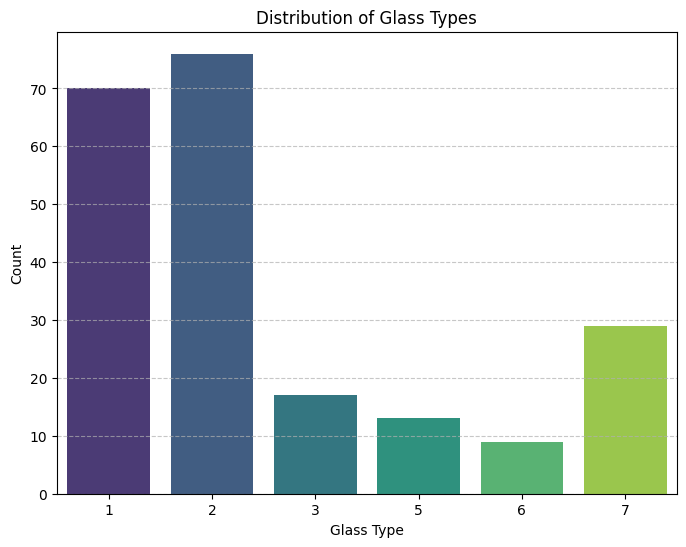

In [60]:
print("\nDistribution of the target variable (Type):")
display(df['Type'].value_counts().sort_index())
plt.figure(figsize=(8, 6))
sns.countplot(x='Type', data=df, palette='viridis')
plt.title('Distribution of Glass Types')
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [53]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.costs = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _hypothesis(self, X, weights, bias):
        return self._sigmoid(np.dot(X, weights) + bias)

    def _cost_function(self, y_true, y_pred):
        epsilon = 1e-10
        return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

    def _compute_gradients(self, X, y_true, y_pred):
        m = X.shape[0]
        dw = (1 / m) * np.dot(X.T, (y_pred - y_true))
        db = (1 / m) * np.sum(y_pred - y_true)
        return dw, db

    def fit_gd(self, X, y):
        #Batch GD
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        for i in range(self.n_iterations):
            y_pred = self._hypothesis(X, self.weights, self.bias)
            dw, db = self._compute_gradients(X, y, y_pred)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            cost = self._cost_function(y, y_pred)
            self.costs.append(cost)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Cost: {cost:.4f}')
        print(f'Final Cost (GD): {self.costs[-1]:.4f}')

    def fit_sgd(self, X, y):
        # Stochastic Gradient Descent
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        if isinstance(y, pd.Series):
            y = y.to_numpy()
        for i in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            epoch_cost = 0
            for j in range(n_samples):
                xi = X_shuffled[j:j+1]
                yi = y_shuffled[j:j+1]
                y_pred_j = self._hypothesis(xi, self.weights, self.bias)
                dw_j = np.dot(xi.T, (y_pred_j - yi))
                db_j = np.sum(y_pred_j - yi)
                self.weights -= self.learning_rate * dw_j
                self.bias -= self.learning_rate * db_j
                epoch_cost += self._cost_function(yi, y_pred_j)
            self.costs.append(epoch_cost / n_samples)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Avg. Cost (SGD): {self.costs[-1]:.4f}')
        print(f'Final Avg. Cost (SGD): {self.costs[-1]:.4f}')

    def fit_mini_batch_gd(self, X, y, batch_size=32):
        # Mini-batch Gradient Descent
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        if isinstance(y, pd.Series):
            y = y.to_numpy()
        for i in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            epoch_cost = 0
            num_batches = int(np.ceil(n_samples / batch_size))
            for j in range(0, n_samples, batch_size):
                X_batch = X_shuffled[j : j + batch_size]
                y_batch = y_shuffled[j : j + batch_size]
                y_pred_batch = self._hypothesis(X_batch, self.weights, self.bias)
                dw_batch, db_batch = self._compute_gradients(X_batch, y_batch, y_pred_batch)
                self.weights -= self.learning_rate * dw_batch
                self.bias -= self.learning_rate * db_batch
                epoch_cost += self._cost_function(y_batch, y_pred_batch)
            self.costs.append(epoch_cost / num_batches)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Avg. Cost (Mini-batch GD): {self.costs[-1]:.4f}')
        print(f'Final Avg. Cost (Mini-batch GD): {self.costs[-1]:.4f}')

    def fit_sgd_momentum(self, X, y, batch_size=32, momentum=0.9):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        v_w = np.zeros(n_features)
        v_b = 0
        if isinstance(y, pd.Series):
            y = y.to_numpy()
        for i in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            epoch_cost = 0
            num_batches = int(np.ceil(n_samples / batch_size))
            for j in range(0, n_samples, batch_size):
                X_batch = X_shuffled[j : j + batch_size]
                y_batch = y_shuffled[j : j + batch_size]
                y_pred_batch = self._hypothesis(X_batch, self.weights, self.bias)
                dw_batch, db_batch = self._compute_gradients(X_batch, y_batch, y_pred_batch)
                v_w = momentum * v_w + self.learning_rate * dw_batch
                v_b = momentum * v_b + self.learning_rate * db_batch
                self.weights -= v_w
                self.bias -= v_b
                epoch_cost += self._cost_function(y_batch, y_pred_batch)
            self.costs.append(epoch_cost / num_batches)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Avg. Cost (SGD with Momentum): {self.costs[-1]:.4f}')
        print(f'Final Avg. Cost (SGD with Momentum): {self.costs[-1]:.4f}')

    def fit_rmsprop(self, X, y, batch_size=32, decay_rate=0.9, epsilon=1e-8):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        s_w = np.zeros(n_features)
        s_b = 0
        if isinstance(y, pd.Series):
            y = y.to_numpy()
        for i in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            epoch_cost = 0
            num_batches = int(np.ceil(n_samples / batch_size))
            for j in range(0, n_samples, batch_size):
                X_batch = X_shuffled[j : j + batch_size]
                y_batch = y_shuffled[j : j + batch_size]
                y_pred_batch = self._hypothesis(X_batch, self.weights, self.bias)
                dw_batch, db_batch = self._compute_gradients(X_batch, y_batch, y_pred_batch)
                s_w = decay_rate * s_w + (1 - decay_rate) * dw_batch**2
                s_b = decay_rate * s_b + (1 - decay_rate) * db_batch**2
                self.weights -= self.learning_rate * dw_batch / (np.sqrt(s_w) + epsilon)
                self.bias -= self.learning_rate * db_batch / (np.sqrt(s_b) + epsilon)
                epoch_cost += self._cost_function(y_batch, y_pred_batch)
            self.costs.append(epoch_cost / num_batches)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Avg. Cost (RMSProp): {self.costs[-1]:.4f}')
        print(f'Final Avg. Cost (RMSProp): {self.costs[-1]:.4f}')

    def fit_adam(self, X, y, batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.costs = []
        m_w, v_w = np.zeros(n_features), np.zeros(n_features)
        m_b, v_b = 0, 0
        t = 0
        if isinstance(y, pd.Series):
            y = y.to_numpy()
        for i in range(self.n_iterations):
            t += 1
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            epoch_cost = 0
            num_batches = int(np.ceil(n_samples / batch_size))
            for j in range(0, n_samples, batch_size):
                X_batch = X_shuffled[j : j + batch_size]
                y_batch = y_shuffled[j : j + batch_size]
                y_pred_batch = self._hypothesis(X_batch, self.weights, self.bias)
                dw_batch, db_batch = self._compute_gradients(X_batch, y_batch, y_pred_batch)
                m_w = beta1 * m_w + (1 - beta1) * dw_batch
                v_w = beta2 * v_w + (1 - beta2) * dw_batch**2
                m_b = beta1 * m_b + (1 - beta1) * db_batch
                v_b = beta2 * v_b + (1 - beta2) * db_batch**2
                m_w_corr = m_w / (1 - beta1**t)
                v_w_corr = v_w / (1 - beta2**t)
                m_b_corr = m_b / (1 - beta1**t)
                v_b_corr = v_b / (1 - beta2**t)
                self.weights -= self.learning_rate * m_w_corr / (np.sqrt(v_w_corr) + epsilon)
                self.bias -= self.learning_rate * m_b_corr / (np.sqrt(v_b_corr) + epsilon)
                epoch_cost += self._cost_function(y_batch, y_pred_batch)
            self.costs.append(epoch_cost / num_batches)
            if (i + 1) % 100 == 0:
                print(f'Iteration {i+1}/{self.n_iterations}, Avg. Cost (Adam): {self.costs[-1]:.4f}')
        print(f'Final Avg. Cost (Adam): {self.costs[-1]:.4f}')

    def predict(self, X):
        y_pred = self._hypothesis(X, self.weights, self.bias)
        return (y_pred >= 0.5).astype(int)


Training Logistic Regression with Gradient Descent (Batch GD) with Learning Rate: 0.05, Iterations: 2000
Iteration 100/2000, Cost: 0.5357
Iteration 200/2000, Cost: 0.5035
Iteration 300/2000, Cost: 0.4886
Iteration 400/2000, Cost: 0.4798
Iteration 500/2000, Cost: 0.4739
Iteration 600/2000, Cost: 0.4697
Iteration 700/2000, Cost: 0.4665
Iteration 800/2000, Cost: 0.4641
Iteration 900/2000, Cost: 0.4622
Iteration 1000/2000, Cost: 0.4606
Iteration 1100/2000, Cost: 0.4594
Iteration 1200/2000, Cost: 0.4583
Iteration 1300/2000, Cost: 0.4574
Iteration 1400/2000, Cost: 0.4567
Iteration 1500/2000, Cost: 0.4561
Iteration 1600/2000, Cost: 0.4555
Iteration 1700/2000, Cost: 0.4550
Iteration 1800/2000, Cost: 0.4546
Iteration 1900/2000, Cost: 0.4543
Iteration 2000/2000, Cost: 0.4539
Final Cost (GD): 0.4539
Training Time (Batch GD): 0.9749 seconds


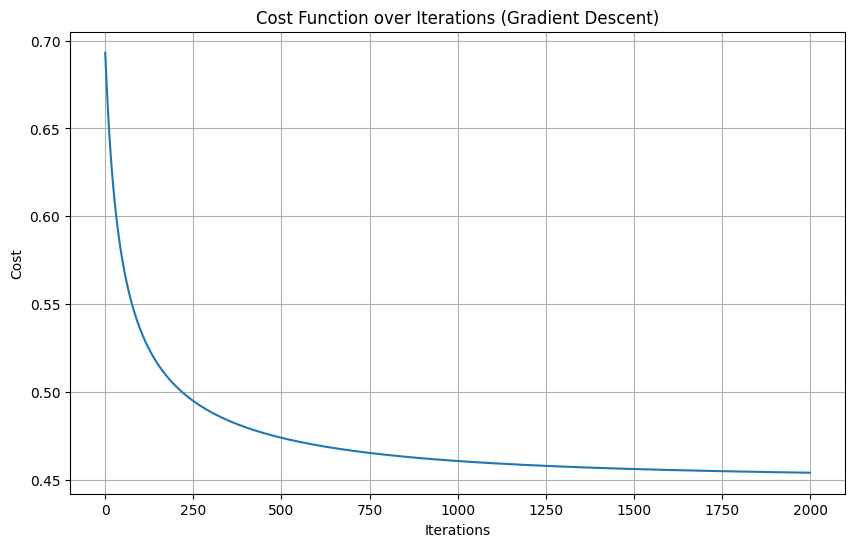

In [54]:
#Hyperparameters for Gradient Descent (Batch GD)
learning_rate_gd = 0.05
n_iterations_gd = 2000
print(f"\nTraining Logistic Regression with Gradient Descent (Batch GD) with Learning Rate: {learning_rate_gd}, Iterations: {n_iterations_gd}")
model_gd = LogisticRegression(learning_rate=learning_rate_gd, n_iterations=n_iterations_gd)
start_time = time.time()
model_gd.fit_gd(X_train, y_train_binary)
end_time = time.time()
training_time_gd = end_time - start_time
print(f"Training Time (Batch GD): {training_time_gd:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_gd.costs)
plt.title('Cost Function over Iterations (Gradient Descent)')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


Training Logistic Regression with Stochastic Gradient Descent (SGD) with Learning Rate: 0.001, Epochs: 1000
Iteration 100/1000, Avg. Cost (SGD): 0.4849
Iteration 200/1000, Avg. Cost (SGD): 0.4674
Iteration 300/1000, Avg. Cost (SGD): 0.4607
Iteration 400/1000, Avg. Cost (SGD): 0.4573
Iteration 500/1000, Avg. Cost (SGD): 0.4554
Iteration 600/1000, Avg. Cost (SGD): 0.4542
Iteration 700/1000, Avg. Cost (SGD): 0.4534
Iteration 800/1000, Avg. Cost (SGD): 0.4528
Iteration 900/1000, Avg. Cost (SGD): 0.4524
Iteration 1000/1000, Avg. Cost (SGD): 0.4520
Final Avg. Cost (SGD): 0.4520
Training Time (SGD): 4.8596 seconds


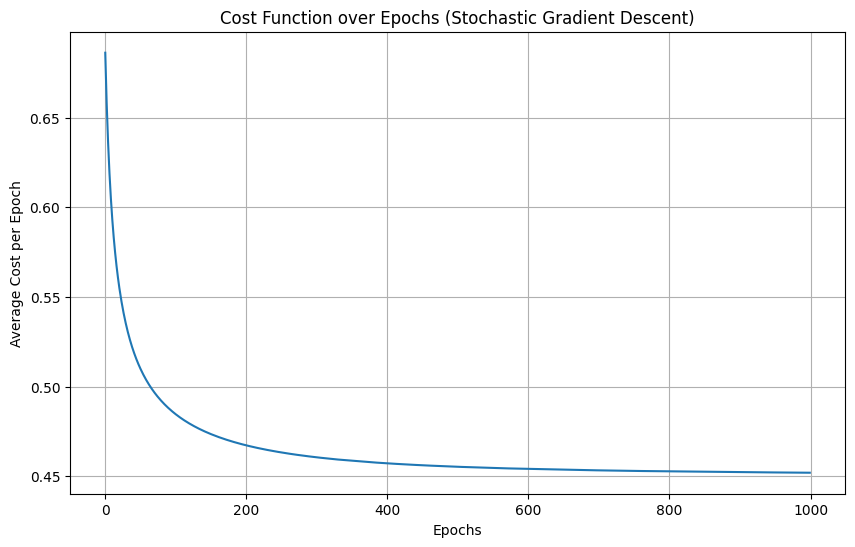

In [55]:
# Hyperparameters for Stochastic Gradient Descent
learning_rate_sgd = 0.001
n_iterations_sgd = 1000
print(f"\nTraining Logistic Regression with Stochastic Gradient Descent (SGD) with Learning Rate: {learning_rate_sgd}, Epochs: {n_iterations_sgd}")
model_sgd = LogisticRegression(learning_rate=learning_rate_sgd, n_iterations=n_iterations_sgd)
start_time = time.time()
model_sgd.fit_sgd(X_train, y_train_binary)
end_time = time.time()
training_time_sgd = end_time - start_time
print(f"Training Time (SGD): {training_time_sgd:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_sgd.costs)
plt.title('Cost Function over Epochs (Stochastic Gradient Descent)')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()


Training Logistic Regression with Mini-batch Gradient Descent (Batch Size: 16) with Learning Rate: 0.01, Epochs: 1500
Iteration 100/1500, Avg. Cost (Mini-batch GD): 0.5031
Iteration 200/1500, Avg. Cost (Mini-batch GD): 0.4723
Iteration 300/1500, Avg. Cost (Mini-batch GD): 0.4700
Iteration 400/1500, Avg. Cost (Mini-batch GD): 0.4613
Iteration 500/1500, Avg. Cost (Mini-batch GD): 0.4572
Iteration 600/1500, Avg. Cost (Mini-batch GD): 0.4560
Iteration 700/1500, Avg. Cost (Mini-batch GD): 0.4555
Iteration 800/1500, Avg. Cost (Mini-batch GD): 0.4558
Iteration 900/1500, Avg. Cost (Mini-batch GD): 0.4527
Iteration 1000/1500, Avg. Cost (Mini-batch GD): 0.4476
Iteration 1100/1500, Avg. Cost (Mini-batch GD): 0.4511
Iteration 1200/1500, Avg. Cost (Mini-batch GD): 0.4491
Iteration 1300/1500, Avg. Cost (Mini-batch GD): 0.4547
Iteration 1400/1500, Avg. Cost (Mini-batch GD): 0.4564
Iteration 1500/1500, Avg. Cost (Mini-batch GD): 0.4494
Final Avg. Cost (Mini-batch GD): 0.4494
Training Time (Mini-batch

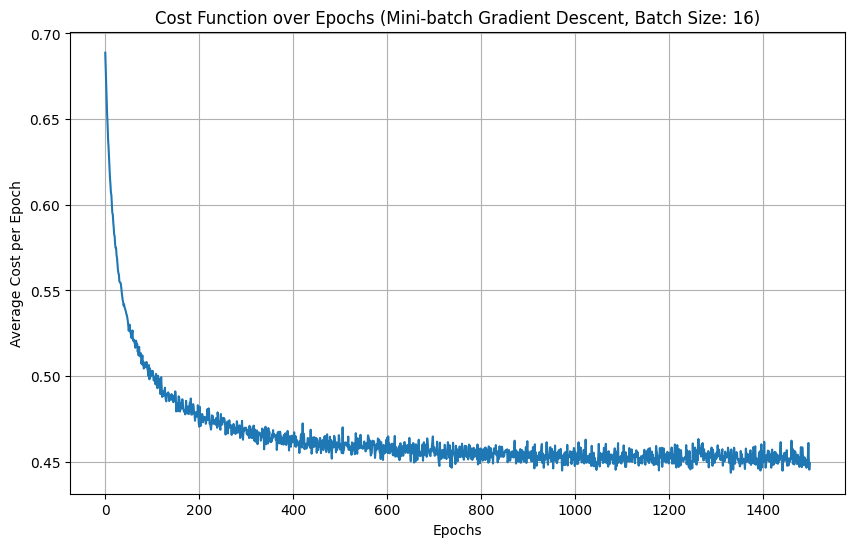

In [51]:
# Hyperparameters for Mini-batch Gradient Descent (Batch Size: 16)
learning_rate_mbgd_16 = 0.01
n_iterations_mbgd_16 = 1500
batch_size_mbgd_16 = 16

print(f"\nTraining Logistic Regression with Mini-batch Gradient Descent (Batch Size: {batch_size_mbgd_16}) with Learning Rate: {learning_rate_mbgd_16}, Epochs: {n_iterations_mbgd_16}")
model_mbgd_16 = LogisticRegression(learning_rate=learning_rate_mbgd_16, n_iterations=n_iterations_mbgd_16)
start_time = time.time()
model_mbgd_16.fit_mini_batch_gd(X_train, y_train_binary, batch_size=batch_size_mbgd_16)
end_time = time.time()
training_time_mbgd_16 = end_time - start_time
print(f"Training Time (Mini-batch GD, Batch Size {batch_size_mbgd_16}): {training_time_mbgd_16:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_mbgd_16.costs)
plt.title(f'Cost Function over Epochs (Mini-batch Gradient Descent, Batch Size: {batch_size_mbgd_16})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()


Training Logistic Regression with Mini-batch Gradient Descent (Batch Size: 32) with Learning Rate: 0.01, Epochs: 1500
Iteration 100/1500, Avg. Cost (Mini-batch GD): 0.5263
Iteration 200/1500, Avg. Cost (Mini-batch GD): 0.5059
Iteration 300/1500, Avg. Cost (Mini-batch GD): 0.4636
Iteration 400/1500, Avg. Cost (Mini-batch GD): 0.4704
Iteration 500/1500, Avg. Cost (Mini-batch GD): 0.4677
Iteration 600/1500, Avg. Cost (Mini-batch GD): 0.4692
Iteration 700/1500, Avg. Cost (Mini-batch GD): 0.4669
Iteration 800/1500, Avg. Cost (Mini-batch GD): 0.4485
Iteration 900/1500, Avg. Cost (Mini-batch GD): 0.4379
Iteration 1000/1500, Avg. Cost (Mini-batch GD): 0.4607
Iteration 1100/1500, Avg. Cost (Mini-batch GD): 0.4613
Iteration 1200/1500, Avg. Cost (Mini-batch GD): 0.4444
Iteration 1300/1500, Avg. Cost (Mini-batch GD): 0.4486
Iteration 1400/1500, Avg. Cost (Mini-batch GD): 0.4696
Iteration 1500/1500, Avg. Cost (Mini-batch GD): 0.4775
Final Avg. Cost (Mini-batch GD): 0.4775
Training Time (Mini-batch

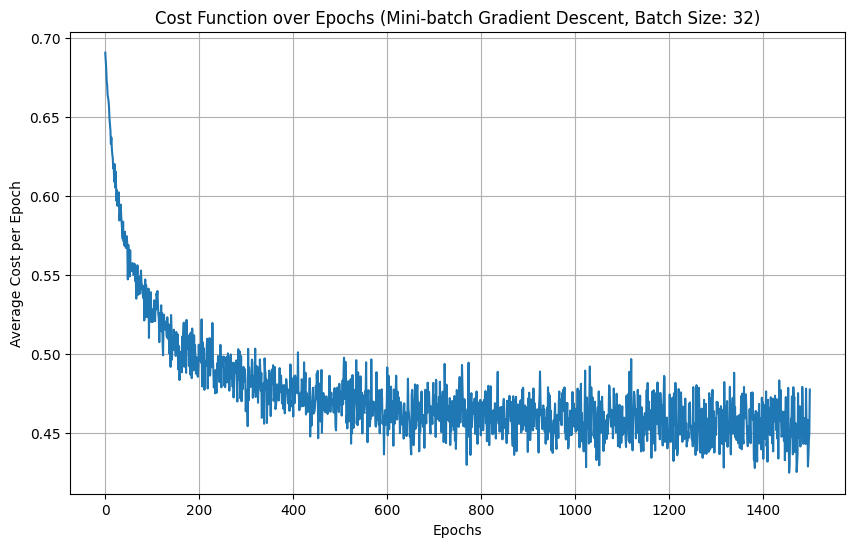

In [56]:
# Hyperparameters for Mini-batch Gradient Descent (Batch Size: 32)
learning_rate_mbgd_32 = 0.01
n_iterations_mbgd_32 = 1500
batch_size_mbgd_32 = 32
print(f"\nTraining Logistic Regression with Mini-batch Gradient Descent (Batch Size: {batch_size_mbgd_32}) with Learning Rate: {learning_rate_mbgd_32}, Epochs: {n_iterations_mbgd_32}")
model_mbgd_32 = LogisticRegression(learning_rate=learning_rate_mbgd_32, n_iterations=n_iterations_mbgd_32)
start_time = time.time()
model_mbgd_32.fit_mini_batch_gd(X_train, y_train_binary, batch_size=batch_size_mbgd_32)
end_time = time.time()
training_time_mbgd_32 = end_time - start_time
print(f"Training Time (Mini-batch GD, Batch Size {batch_size_mbgd_32}): {training_time_mbgd_32:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_mbgd_32.costs)
plt.title(f'Cost Function over Epochs (Mini-batch Gradient Descent, Batch Size: {batch_size_mbgd_32})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()


Training Logistic Regression with Mini-batch Gradient Descent (Batch Size: 64) with Learning Rate: 0.01, Epochs: 1500
Iteration 100/1500, Avg. Cost (Mini-batch GD): 0.5659
Iteration 200/1500, Avg. Cost (Mini-batch GD): 0.5226
Iteration 300/1500, Avg. Cost (Mini-batch GD): 0.5152
Iteration 400/1500, Avg. Cost (Mini-batch GD): 0.4988
Iteration 500/1500, Avg. Cost (Mini-batch GD): 0.4938
Iteration 600/1500, Avg. Cost (Mini-batch GD): 0.4911
Iteration 700/1500, Avg. Cost (Mini-batch GD): 0.4820
Iteration 800/1500, Avg. Cost (Mini-batch GD): 0.4768
Iteration 900/1500, Avg. Cost (Mini-batch GD): 0.4765
Iteration 1000/1500, Avg. Cost (Mini-batch GD): 0.4712
Iteration 1100/1500, Avg. Cost (Mini-batch GD): 0.4779
Iteration 1200/1500, Avg. Cost (Mini-batch GD): 0.4629
Iteration 1300/1500, Avg. Cost (Mini-batch GD): 0.4658
Iteration 1400/1500, Avg. Cost (Mini-batch GD): 0.4689
Iteration 1500/1500, Avg. Cost (Mini-batch GD): 0.4586
Final Avg. Cost (Mini-batch GD): 0.4586
Training Time (Mini-batch

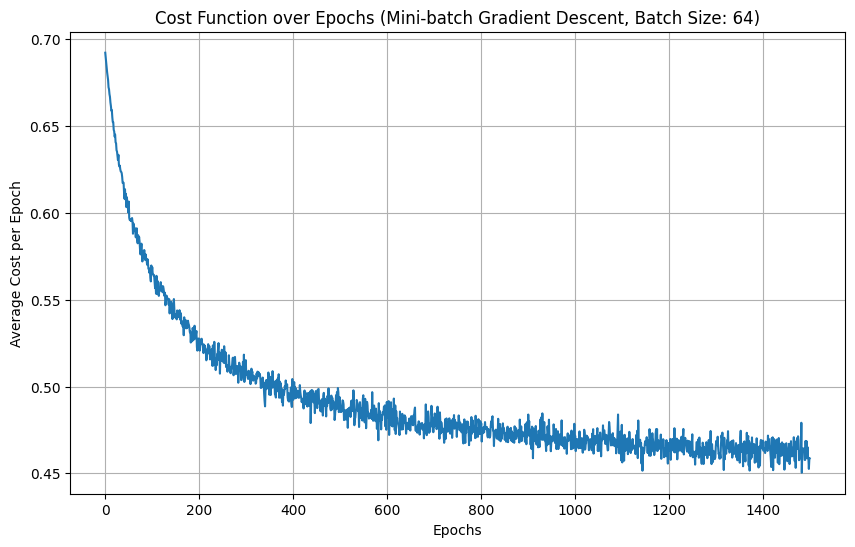

In [52]:
# Hyperparameters for Mini-batch Gradient Descent (Batch Size: 64)
learning_rate_mbgd_64 = 0.01
n_iterations_mbgd_64 = 1500
batch_size_mbgd_64 = 64

print(f"\nTraining Logistic Regression with Mini-batch Gradient Descent (Batch Size: {batch_size_mbgd_64}) with Learning Rate: {learning_rate_mbgd_64}, Epochs: {n_iterations_mbgd_64}")
model_mbgd_64 = LogisticRegression(learning_rate=learning_rate_mbgd_64, n_iterations=n_iterations_mbgd_64)
start_time = time.time()
model_mbgd_64.fit_mini_batch_gd(X_train, y_train_binary, batch_size=batch_size_mbgd_64)
end_time = time.time()
training_time_mbgd_64 = end_time - start_time
print(f"Training Time (Mini-batch GD, Batch Size {batch_size_mbgd_64}): {training_time_mbgd_64:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_mbgd_64.costs)
plt.title(f'Cost Function over Epochs (Mini-batch Gradient Descent, Batch Size: {batch_size_mbgd_64})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()

In [57]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0) # zero_division=0 to handle cases where no positive predictions are made
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)

# Evaluate Gradient Descent model
evaluate_model(model_gd, X_test, y_test_binary, "Gradient Descent (Batch GD)")
# Evaluate Stochastic Gradient Descent model
evaluate_model(model_sgd, X_test, y_test_binary, "Stochastic Gradient Descent (SGD)")
# Evaluate Mini-batch Gradient Descent models
evaluate_model(model_mbgd_16, X_test, y_test_binary, "Mini-batch Gradient Descent (Batch Size: 16)")
evaluate_model(model_mbgd_32, X_test, y_test_binary, "Mini-batch Gradient Descent (Batch Size: 32)")
evaluate_model(model_mbgd_64, X_test, y_test_binary, "Mini-batch Gradient Descent (Batch Size: 64)")


--- Gradient Descent (Batch GD) Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]

--- Stochastic Gradient Descent (SGD) Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]

--- Mini-batch Gradient Descent (Batch Size: 16) Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]

--- Mini-batch Gradient Descent (Batch Size: 32) Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]

--- Mini-batch Gradient Descent (Batch Size: 64) Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]


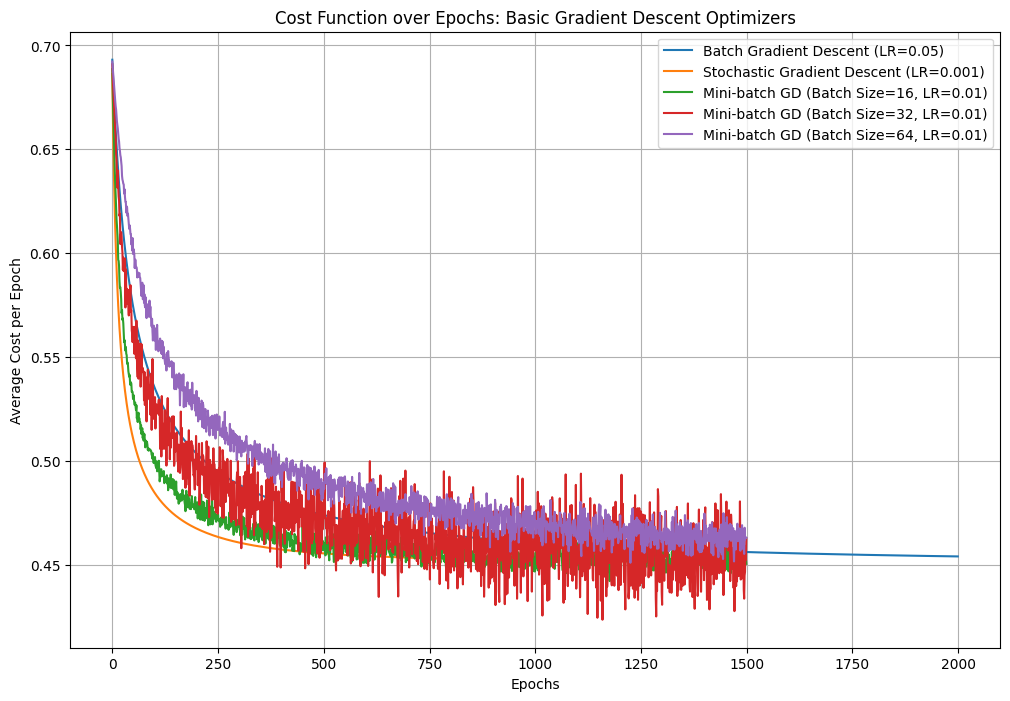

In [43]:
plt.figure(figsize=(12, 8))
plt.plot(model_gd.costs, label='Batch Gradient Descent (LR=0.05)')
plt.plot(model_sgd.costs, label='Stochastic Gradient Descent (LR=0.001)')
plt.plot(model_mbgd_16.costs, label='Mini-batch GD (Batch Size=16, LR=0.01)')
plt.plot(model_mbgd_32.costs, label='Mini-batch GD (Batch Size=32, LR=0.01)')
plt.plot(model_mbgd_64.costs, label='Mini-batch GD (Batch Size=64, LR=0.01)')
plt.title('Cost Function over Epochs: Basic Gradient Descent Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.legend()
plt.grid(True)
plt.show()


Training Logistic Regression with SGD with Momentum (Batch Size: 32)
Learning Rate: 0.01, Epochs: 1500, Momentum: 0.9
Iteration 100/1500, Avg. Cost (SGD with Momentum): 0.4603
Iteration 200/1500, Avg. Cost (SGD with Momentum): 0.4448
Iteration 300/1500, Avg. Cost (SGD with Momentum): 0.4452
Iteration 400/1500, Avg. Cost (SGD with Momentum): 0.4528
Iteration 500/1500, Avg. Cost (SGD with Momentum): 0.4412
Iteration 600/1500, Avg. Cost (SGD with Momentum): 0.4432
Iteration 700/1500, Avg. Cost (SGD with Momentum): 0.4398
Iteration 800/1500, Avg. Cost (SGD with Momentum): 0.4432
Iteration 900/1500, Avg. Cost (SGD with Momentum): 0.4532
Iteration 1000/1500, Avg. Cost (SGD with Momentum): 0.4506
Iteration 1100/1500, Avg. Cost (SGD with Momentum): 0.4460
Iteration 1200/1500, Avg. Cost (SGD with Momentum): 0.4341
Iteration 1300/1500, Avg. Cost (SGD with Momentum): 0.4582
Iteration 1400/1500, Avg. Cost (SGD with Momentum): 0.4604
Iteration 1500/1500, Avg. Cost (SGD with Momentum): 0.4532
Final

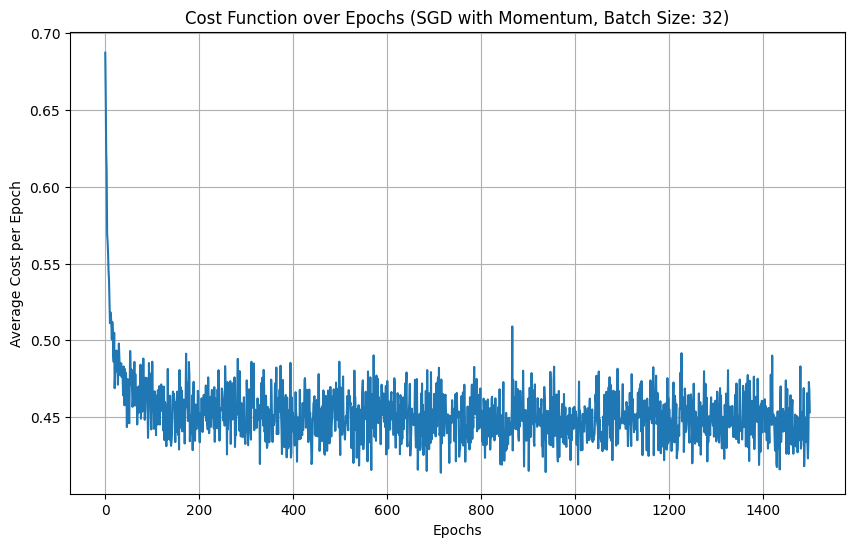

In [45]:
#Hyperparameters for SGD with Momentum Evaluation
learning_rate_sgd_momentum = 0.01
n_iterations_sgd_momentum = 1500
batch_size_sgd_momentum = 32
momentum_sgd = 0.9

print(f"\nTraining Logistic Regression with SGD with Momentum (Batch Size: {batch_size_sgd_momentum})\nLearning Rate: {learning_rate_sgd_momentum}, Epochs: {n_iterations_sgd_momentum}, Momentum: {momentum_sgd}")
model_sgd_momentum = LogisticRegression(learning_rate=learning_rate_sgd_momentum, n_iterations=n_iterations_sgd_momentum)
start_time = time.time()
model_sgd_momentum.fit_sgd_momentum(X_train, y_train_binary, batch_size=batch_size_sgd_momentum, momentum=momentum_sgd)
end_time = time.time()
training_time_sgd_momentum = end_time - start_time
print(f"Training Time (SGD with Momentum): {training_time_sgd_momentum:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_sgd_momentum.costs)
plt.title(f'Cost Function over Epochs (SGD with Momentum, Batch Size: {batch_size_sgd_momentum})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()

In [46]:
evaluate_model(model_sgd_momentum, X_test, y_test_binary, "SGD with Momentum")


--- SGD with Momentum Evaluation ---
Accuracy: 0.8605
Precision: 0.7273
Recall: 0.7273
F1-Score: 0.7273
Confusion Matrix:
[[29  3]
 [ 3  8]]



Training Logistic Regression with RMSProp (Batch Size: 32)
Learning Rate: 0.001, Epochs: 1500, Decay Rate: 0.9
Iteration 100/1500, Avg. Cost (RMSProp): 0.5331
Iteration 200/1500, Avg. Cost (RMSProp): 0.4824
Iteration 300/1500, Avg. Cost (RMSProp): 0.4635
Iteration 400/1500, Avg. Cost (RMSProp): 0.4703
Iteration 500/1500, Avg. Cost (RMSProp): 0.4522
Iteration 600/1500, Avg. Cost (RMSProp): 0.4542
Iteration 700/1500, Avg. Cost (RMSProp): 0.4400
Iteration 800/1500, Avg. Cost (RMSProp): 0.4688
Iteration 900/1500, Avg. Cost (RMSProp): 0.4616
Iteration 1000/1500, Avg. Cost (RMSProp): 0.4407
Iteration 1100/1500, Avg. Cost (RMSProp): 0.4556
Iteration 1200/1500, Avg. Cost (RMSProp): 0.4564
Iteration 1300/1500, Avg. Cost (RMSProp): 0.4566
Iteration 1400/1500, Avg. Cost (RMSProp): 0.4514
Iteration 1500/1500, Avg. Cost (RMSProp): 0.4408
Final Avg. Cost (RMSProp): 0.4408
Training Time (RMSProp): 0.4016 seconds


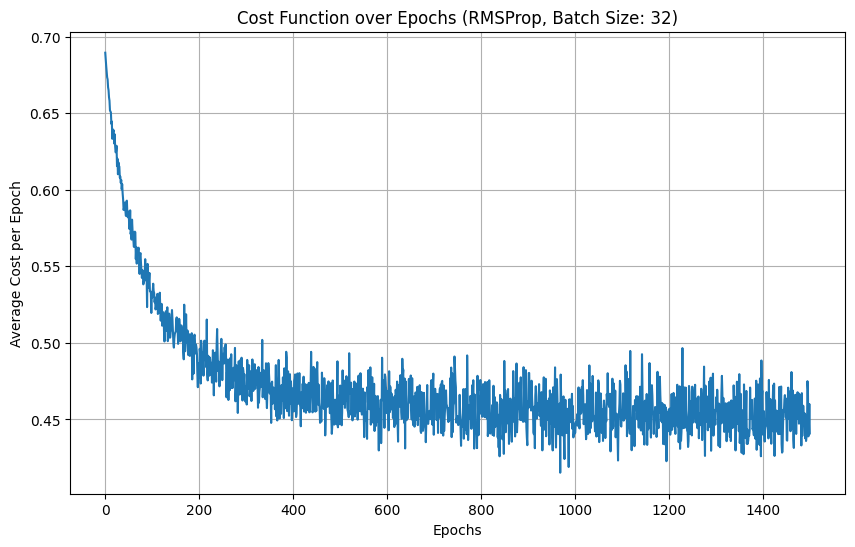

In [47]:
#Hyperparameters for RMSprop Evaluation
learning_rate_rmsprop = 0.001
n_iterations_rmsprop = 1500
batch_size_rmsprop = 32
decay_rate_rmsprop = 0.9

print(f"\nTraining Logistic Regression with RMSProp (Batch Size: {batch_size_rmsprop})\nLearning Rate: {learning_rate_rmsprop}, Epochs: {n_iterations_rmsprop}, Decay Rate: {decay_rate_rmsprop}")
model_rmsprop = LogisticRegression(learning_rate=learning_rate_rmsprop, n_iterations=n_iterations_rmsprop)
start_time = time.time()
model_rmsprop.fit_rmsprop(X_train, y_train_binary, batch_size=batch_size_rmsprop, decay_rate=decay_rate_rmsprop)
end_time = time.time()
training_time_rmsprop = end_time - start_time
print(f"Training Time (RMSProp): {training_time_rmsprop:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_rmsprop.costs)
plt.title(f'Cost Function over Epochs (RMSProp, Batch Size: {batch_size_rmsprop})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()

In [48]:
evaluate_model(model_rmsprop, X_test, y_test_binary, "RMSProp")


--- RMSProp Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]



Training Logistic Regression with Adam (Batch Size: 32)
Learning Rate: 0.001, Epochs: 1500, Beta1: 0.9, Beta2: 0.999
Iteration 100/1500, Avg. Cost (Adam): 0.5747
Iteration 200/1500, Avg. Cost (Adam): 0.5464
Iteration 300/1500, Avg. Cost (Adam): 0.5061
Iteration 400/1500, Avg. Cost (Adam): 0.4984
Iteration 500/1500, Avg. Cost (Adam): 0.4765
Iteration 600/1500, Avg. Cost (Adam): 0.4890
Iteration 700/1500, Avg. Cost (Adam): 0.4603
Iteration 800/1500, Avg. Cost (Adam): 0.4639
Iteration 900/1500, Avg. Cost (Adam): 0.4478
Iteration 1000/1500, Avg. Cost (Adam): 0.4398
Iteration 1100/1500, Avg. Cost (Adam): 0.4854
Iteration 1200/1500, Avg. Cost (Adam): 0.4836
Iteration 1300/1500, Avg. Cost (Adam): 0.4543
Iteration 1400/1500, Avg. Cost (Adam): 0.4567
Iteration 1500/1500, Avg. Cost (Adam): 0.4484
Final Avg. Cost (Adam): 0.4484
Training Time (Adam): 0.4689 seconds


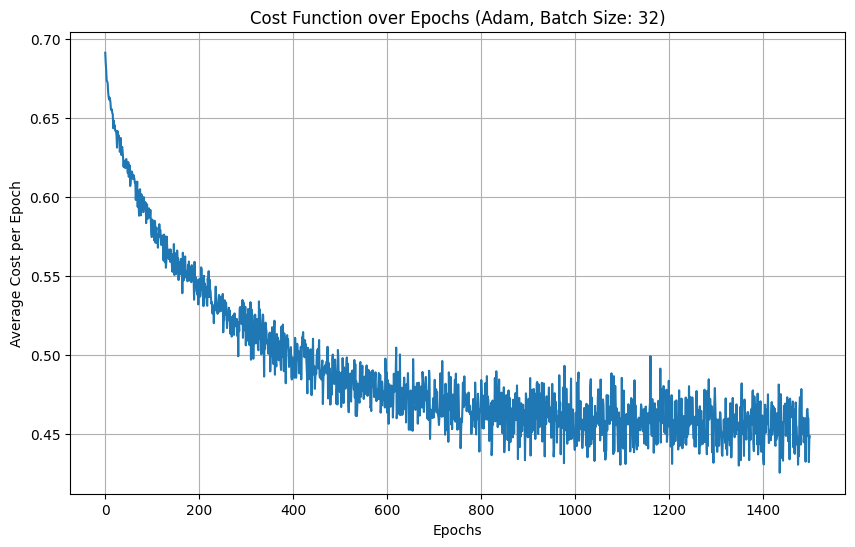

In [49]:
# Hyperparameters for Adam
learning_rate_adam = 0.001
n_iterations_adam = 1500
batch_size_adam = 32
beta1_adam = 0.9
beta2_adam = 0.999

print(f"\nTraining Logistic Regression with Adam (Batch Size: {batch_size_adam})\nLearning Rate: {learning_rate_adam}, Epochs: {n_iterations_adam}, Beta1: {beta1_adam}, Beta2: {beta2_adam}")
model_adam = LogisticRegression(learning_rate=learning_rate_adam, n_iterations=n_iterations_adam)
start_time = time.time()
model_adam.fit_adam(X_train, y_train_binary, batch_size=batch_size_adam, beta1=beta1_adam, beta2=beta2_adam)
end_time = time.time()
training_time_adam = end_time - start_time
print(f"Training Time (Adam): {training_time_adam:.4f} seconds")
plt.figure(figsize=(10, 6))
plt.plot(model_adam.costs)
plt.title(f'Cost Function over Epochs (Adam, Batch Size: {batch_size_adam})')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.grid(True)
plt.show()

In [50]:
evaluate_model(model_adam, X_test, y_test_binary, "Adam")


--- Adam Evaluation ---
Accuracy: 0.8372
Precision: 0.7000
Recall: 0.6364
F1-Score: 0.6667
Confusion Matrix:
[[29  3]
 [ 4  7]]


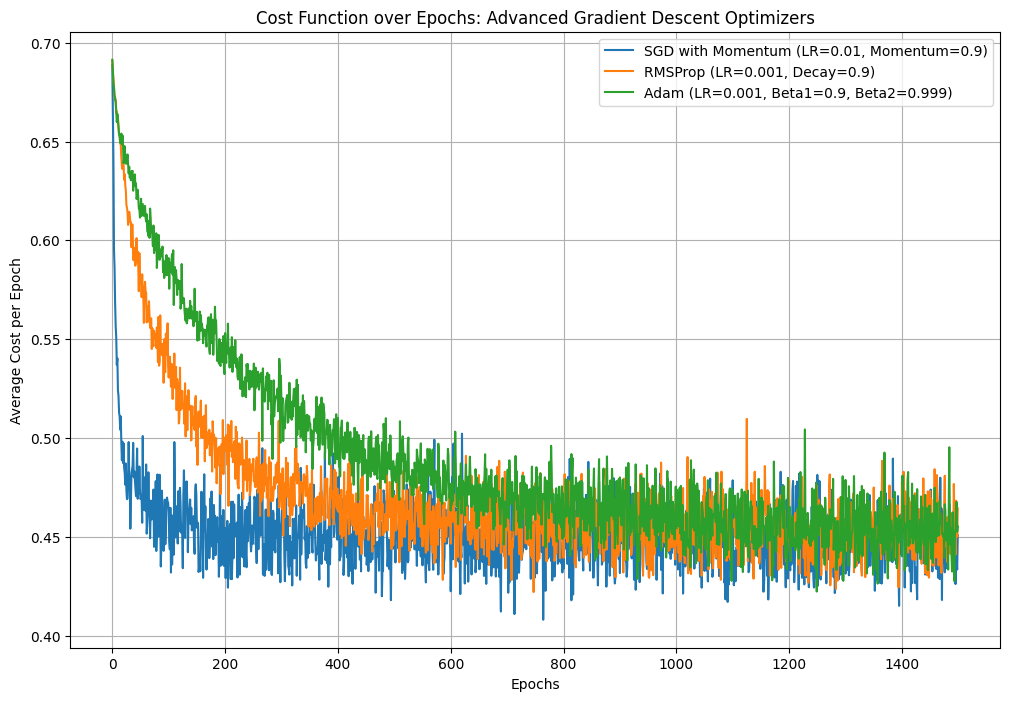

In [44]:
plt.figure(figsize=(12, 8))
plt.plot(model_sgd_momentum.costs, label='SGD with Momentum (LR=0.01, Momentum=0.9)')
plt.plot(model_rmsprop.costs, label='RMSProp (LR=0.001, Decay=0.9)')
plt.plot(model_adam.costs, label='Adam (LR=0.001, Beta1=0.9, Beta2=0.999)')
plt.title('Cost Function over Epochs: Advanced Gradient Descent Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Average Cost per Epoch')
plt.legend()
plt.grid(True)
plt.show()